<a href="https://colab.research.google.com/github/RonGopal/intro_to_AI/blob/main/Assignment12rrg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2
from google.colab import drive
drive.mount('/content/drive')
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#Loading CSV file
csv_path = "/content/drive/MyDrive/Assignment12rrg/styles.csv"
df = pd.read_csv(csv_path, on_bad_lines='skip')

df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [3]:
image_dir = "/content/drive/MyDrive/Assignment12rrg/images"

images = []
labels = []

# Loading images and matching them to the labels

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg") or filename.endswith(".png"):

        # Extract ID from filename: "1557.jpg" → 1557
        img_id = int(filename.replace(".jpg", "").replace(".png", ""))

        # Look up label in CSV
        row = df[df['id'] == img_id]

        # Skip if ID not found
        if row.empty:
            continue

        label = row['subCategory'].values[0]

        # Load image
        img_path = os.path.join(image_dir, filename)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize (choose size based on your model)
        img = cv2.resize(img, (64, 64))

        images.append(img)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Loaded images:", images.shape)
print("Loaded labels:", labels.shape)

Loaded images: (44419, 64, 64, 3)
Loaded labels: (44419,)


In [4]:
# Encode string labels → integers
le = LabelEncoder()
y_encoded = le.fit_transform(labels)

# One-hot encode for softmax output
y_onehot = to_categorical(y_encoded)

print("Number of classes:", len(le.classes_))

Number of classes: 45


In [5]:
# Normailizing image pixel values
X = images.astype("float32") / 255.0

In [6]:
# Count samples per class
unique, counts = np.unique(labels, return_counts=True)
class_counts = dict(zip(unique, counts))

# Keep only classes with at least 2 samples
valid_classes = [cls for cls, cnt in class_counts.items() if cnt >= 2]

# Filter dataset
mask = np.isin(labels, valid_classes)
X_filtered = X[mask]
y_filtered = y_onehot[mask]
labels_filtered = labels[mask]

print("Filtered dataset:", X_filtered.shape, labels_filtered.shape)

Filtered dataset: (44417, 64, 64, 3) (44417,)


In [7]:
# Training/test split data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

In [8]:
# Simple feed forward nerual network
model = Sequential([
    Flatten(input_shape=(64, 64, 3)),     # Flatten image into 1D vector
    Dense(256, activation='relu'),        # Hidden layer 1
    Dense(128, activation='relu'),        # Hidden layer 2
    Dense(len(le.classes_), activation='softmax')  # Output layer
])

# Compiling with adam
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 45)             │         5,805 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,184,685 (12.15 MB)

 Trainable params: 3,184,685 (12.15 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Training model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.6841 - loss: 1.2849 - val_accuracy: 0.7284 - val_loss: 0.9959
Epoch 2/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.7647 - loss: 0.8474 - val_accuracy: 0.7916 - val_loss: 0.7818
Epoch 3/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.7931 - loss: 0.7337 - val_accuracy: 0.8206 - val_loss: 0.6474
Epoch 4/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.8049 - loss: 0.6917 - val_accuracy: 0.7645 - val_loss: 0.7672
Epoch 5/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.8166 - loss: 0.6415 - val_accuracy: 0.8103 - val_loss: 0.6906
Epoch 6/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.8206 - loss: 0.6283 - val_accuracy: 0.8392 - val_loss: 0.6092
Epoch 7/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.8270 - loss: 0.5950 - val_accuracy: 0.8334 - val_loss: 0.6221
Epoch 8/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8350 - loss: 0.5780 - 

In [10]:
#Making Predicitions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [11]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

Accuracy: 0.8470283656010806
Precision: 0.8508663781303123
Recall: 0.8470283656010806
F1 Score: 0.8426100247204008


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


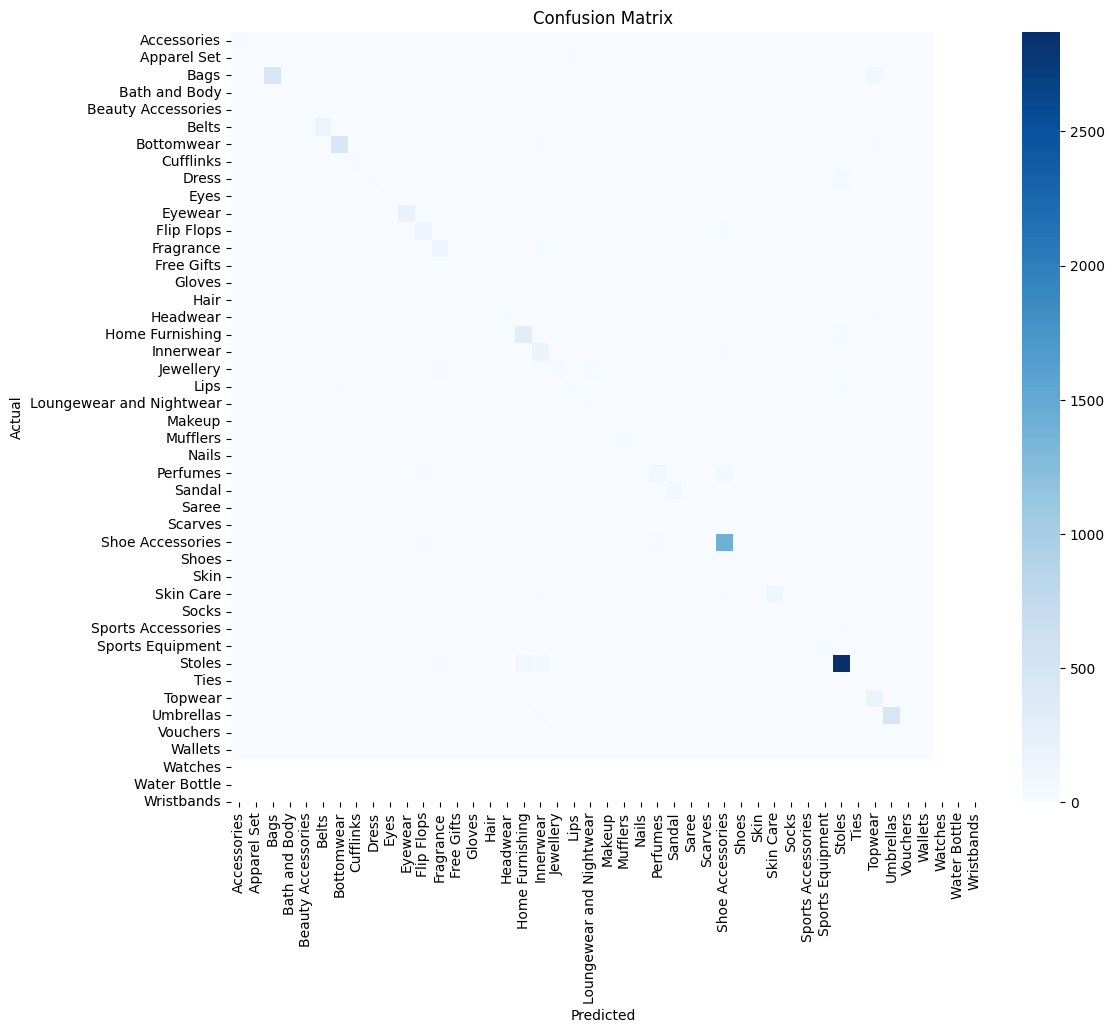

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
unique_labels_in_test_set = np.unique(y_true)
correct_target_names = le.inverse_transform(unique_labels_in_test_set)

print(classification_report(y_true, y_pred, labels=unique_labels_in_test_set, target_names=correct_target_names, zero_division=0))

                          precision    recall  f1-score   support

             Accessories       0.82      0.69      0.75        26
             Apparel Set       0.71      0.24      0.36        21
                    Bags       0.93      0.78      0.85       611
           Bath and Body       0.00      0.00      0.00         2
      Beauty Accessories       0.00      0.00      0.00         1
                   Belts       0.86      0.94      0.90       162
              Bottomwear       0.92      0.85      0.88       539
               Cufflinks       0.67      0.86      0.75        21
                   Dress       0.41      0.12      0.19        96
                    Eyes       0.00      0.00      0.00         8
                 Eyewear       0.97      0.99      0.98       215
              Flip Flops       0.59      0.79      0.68       183
               Fragrance       0.61      0.68      0.64       202
              Free Gifts       0.00      0.00      0.00        21
         

In [18]:
def predict_new_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Image not loaded from {img_path}. Please check the path.")
        return None # Return None or raise an error as appropriate

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (64, 64))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_idx = np.argmax(pred)
    return le.classes_[class_idx]

# test01 is a white t-shirt
predicted_class = predict_new_image("/content/drive/MyDrive/Assignment12rrg/test_images/test01.jpg")
if predicted_class is not None:
    print(predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Topwear


In [20]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2 # Define validation split here for the generator
)

# Create training and validation generators
train_generator = datagen.flow(
    X_train, y_train,
    batch_size=32,
    subset='training' # Specify subset for training data
)

validation_generator = datagen.flow(
    X_train, y_train,
    batch_size=32,
    subset='validation' # Specify subset for validation data
)

# Fit the model using the generators
history_aug = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator # Pass validation_data separately
)

Epoch 1/15
889/889 ━━━━━━━━━━━━━━━━━━━━ 54s 60ms/step - accuracy: 0.5900 - loss: 1.5127 - val_accuracy: 0.5753 - val_loss: 1.5726
Epoch 2/15
889/889 ━━━━━━━━━━━━━━━━━━━━ 52s 59ms/step - accuracy: 0.6388 - loss: 1.2690 - val_accuracy: 0.6537 - val_loss: 1.2319
Epoch 3/15
889/889 ━━━━━━━━━━━━━━━━━━━━ 51s 57ms/step - accuracy: 0.6554 - loss: 1.2122 - val_accuracy: 0.6682 - val_loss: 1.1449
Epoch 4/15
889/889 ━━━━━━━━━━━━━━━━━━━━ 49s 55ms/step - accuracy: 0.6650 - loss: 1.1656 - val_accuracy: 0.6649 - val_loss: 1.1632
Epoch 5/15
889/889 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - accuracy: 0.6702 - loss: 1.1461 - val_accuracy: 0.6433 - val_loss: 1.2049
Epoch 6/15
889/889 ━━━━━━━━━━━━━━━━━━━━ 57s 64ms/step - accuracy: 0.6819 - loss: 1.1033 - val_accuracy: 0.6680 - val_loss: 1.1690
Epoch 7/15
889/889 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.6824 - loss: 1.1135 - val_accuracy: 0.6889 - val_loss: 1.0933
Epoch 8/15
889/889 ━━━━━━━━━━━━━━━━━━━━ 78s 63ms/step - accuracy: 0.6899 - loss: 1.0749 - 

Feedforward neural network for fashion items had an accuracy of 85% in all of the tests. The larger the sample size the more accurate the results were i.e. top wear had over 3000 entries and had an accuracy of 95% while things like water bottle had one one entry and couldn't categorize it. Categories were general enough that it could easily identitfy them. This dataset had another sub category but it was so granular that it would stop the process or return some the worst accuracy, F1-score etc. this was due to the fact that there were too many categories. it was accurate with the test image as well, knowing what I gave it (a white t-shirt) was topwear. Where it failed was there was a few items in a specific category so to balance it out the datset needs a even amount of all fashion wear